Resume Job Category Classifier - Basic EDA 

In [59]:
# Import Required Libraries

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

# Ignore warnings 
warnings.filterwarnings("ignore")
 
# Set plot style 
sns.set_style("whitegrid")

In [60]:
# Load Dataset

df = pd.read_csv("../data/resume_data.csv", on_bad_lines="skip")
df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [61]:
# Strip BOM and surrounding whitespace from column names (fixes KeyError)
df.columns = df.columns.str.replace('\ufeff', '', regex=False)
df.columns = df.columns.str.strip()

# Keep only important columns
df = df[["career_objective", "skills", "responsibilities", "job_position_name"]]

# Rename column for easier understanding 
df = df.rename( columns={"job_position_name": "job_position"} )
df.head()

,career_objective,skills,responsibilities,job_position
0,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",Technical Support\nTroubleshooting\nCollaborat...,Senior Software Engineer
1,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...",Machine Learning Leadership\nCross-Functional ...,Machine Learning (ML) Engineer
2,NaN,"['Software Development', 'Machine Learning', '...","Trade Marketing Executive\nBrand Visibility, S...","Executive/ Senior Executive- Trade Marketing, ..."
3,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...",Apparel Sourcing\nQuality Garment Sourcing\nRe...,Business Development Executive
4,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",iOS Lifecycle\nRequirement Analysis\nNative Fr...,Senior iOS Engineer


In [62]:
# check missing values
df.isnull().sum()


career_objective    4804
skills                56
responsibilities       0
job_position           0
dtype: int64

In [63]:
# handling missing values 
df.dropna(subset=["skills"], inplace=True)
df.fillna("", inplace=True)
df.isnull().sum()

career_objective    0
skills              0
responsibilities    0
job_position        0
dtype: int64

In [64]:
#combine all text columns into a single column for easier processing
df["combined_text"] = df["career_objective"] + " " + df["skills"] + " " + df["responsibilities"]

#keep only the combined text and job position columns for further analysis
df = df[["combined_text", "job_position"]]
df.head()

,combined_text,job_position
0,Big data analytics working and database wareho...,Senior Software Engineer
1,Fresher looking to join as a data analyst and ...,Machine Learning (ML) Engineer
2,"['Software Development', 'Machine Learning', ...","Executive/ Senior Executive- Trade Marketing, ..."
3,To obtain a position in a fast-paced business ...,Business Development Executive
4,Professional accountant with an outstanding wo...,Senior iOS Engineer


In [65]:
#Normalize job position labels (e.g., "Data Scientist" and "Data Science" should be treated as the same category)
def normalize_label(title):

    title = str(title).lower()

    # Data Science / AI
    if (
        'machine learning' in title or
        'ml engineer' in title or
        'ai engineer' in title or
        'data science' in title or
        'data engineer' in title or
        'generative ai' in title
    ):
        return 'Data Science'

    # Software Development
    elif (
        'software engineer' in title or
        'full stack' in title or
        'developer' in title
    ):
        return 'Software Development'

    # DevOps / Cloud / System
    elif (
        'devops' in title or
        'system administrator' in title or
        'network support' in title or
        'database administrator' in title or
        'dba' in title
    ):
        return 'Cloud & DevOps'

    # Mobile Development
    elif (
        'ios engineer' in title or
        'android' in title or
        'mobile' in title
    ):
        return 'Mobile Development'

    # Civil Engineering
    elif (
        'civil engineer' in title or
        'site engineer' in title or
        'project coordinator' in title
    ):
        return 'Civil Engineering'

    # Mechanical Engineering
    elif (
        'mechanical' in title
    ):
        return 'Mechanical Engineering'

    # Human Resources
    elif (
        'hr' in title or
        'human resource' in title
    ):
        return 'Human Resources'

    # Marketing / Sales
    elif (
        'marketing' in title or
        'business development' in title or
        'trade marketing' in title
    ):
        return 'Marketing & Sales'

    # Finance / Audit
    elif (
        'audit' in title or
        'vat' in title or
        'compliance' in title or
        'internal control' in title
    ):
        return 'Finance & Audit'

    # Management / Administration
    elif (
        'manager' in title or
        'administrative' in title
    ):
        return 'Management'

    else:
        return 'Other'

In [66]:
#Apply normalization function to job position column
df["job_position"] = df["job_position"].apply(normalize_label)

#Remove rows with "Other" job position (if desired)
df = df[df["job_position"] != "Other"]

#Keep final dataset for modeling
final_df = df[["combined_text", "job_position"]]
final_df.head()

,combined_text,job_position
0,Big data analytics working and database wareho...,Software Development
1,Fresher looking to join as a data analyst and ...,Data Science
2,"['Software Development', 'Machine Learning', ...",Marketing & Sales
3,To obtain a position in a fast-paced business ...,Marketing & Sales
4,Professional accountant with an outstanding wo...,Mobile Development


In [67]:
#Basic dataset information
print("\nFinal Dataset Shape:")
print(final_df.shape)

print("\nCategory Distribution:")
print(final_df["job_position"].value_counts())


Final Dataset Shape:
(9150, 2)

Category Distribution:
job_position
Data Science              1691
Cloud & DevOps            1355
Civil Engineering         1020
Finance & Audit           1017
Marketing & Sales         1017
Mechanical Engineering    1017
Human Resources            679
Software Development       677
Management                 339
Mobile Development         338
Name: count, dtype: int64


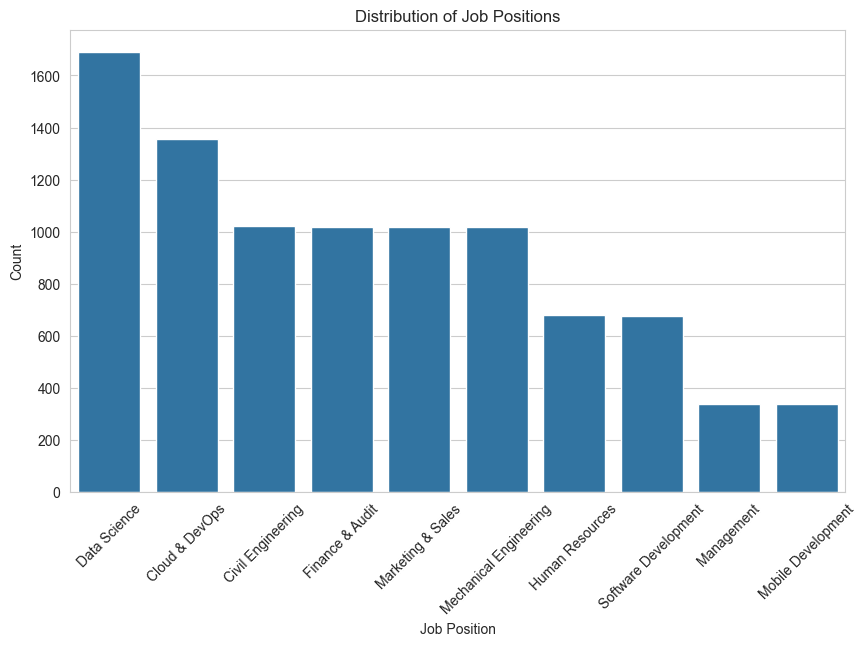

In [68]:
#Visualization - Category Distribution

plt.figure(figsize=(10,6))
sns.countplot(data=final_df, x="job_position", order=final_df["job_position"].value_counts().index)
plt.title("Distribution of Job Positions")
plt.xlabel("Job Position")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [69]:
# Save the final cleaned dataset for modeling
final_df.to_csv("../data/final_resume_data.csv", index=False)
print("\nFinal cleaned dataset saved to '../data/final_resume_data.csv' successfully!")


Final cleaned dataset saved to '../data/final_resume_data.csv' successfully!


EDA summary

In [71]:
print("\n================ EDA SUMMARY ================")

print(f"Total Rows: {final_df.shape[0]}") 
print(f"Total Columns: {final_df.shape[1]}")

print("\nAvailable Categories:") 
print(final_df['job_position'].unique())


================ EDA SUMMARY ================
Total Rows: 9150
Total Columns: 2

Available Categories:
['Software Development' 'Data Science' 'Marketing & Sales'
 'Mobile Development' 'Mechanical Engineering' 'Management'
 'Cloud & DevOps' 'Civil Engineering' 'Finance & Audit' 'Human Resources']
